# Notebook 7 — Correlation & Regression: Inference vs Prediction

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 7 — Correlation & Regression**. The lecture covered Pearson vs. Spearman correlation, the linear regression model (least squares, residuals, assumptions), cases where linear regression fails on low-dimensional data (e.g. circular relationships), polynomial terms and interactions, and robust regression for outliers and heavy tails.

In this notebook we put those ideas into practice on a behavioural dataset, and along the way we build up the coding skills that go with them: scatter plots, correlation functions, `statsmodels` regression and design matrices, polynomial fits, train/test splits, cross-validation, and residual diagnostics.

> **A note on the dataset.** This notebook uses the **IBL mouse behaviour** already seen from Week 3 onwards (`notebooks/data/ibl_2afc.csv.gz`, described in `ibl_2afc_datadictionary.md`). We work at the level of the **training session**: every point is one mouse on one day, summarised by how accurate it was, how fast it was answering, and how many trials it got through. Everything is real behaviour, except the angle pair in Section 8, which stays simulated because a two-choice task has no orientation to report.

### By the end of this notebook you will be able to
- Build scatter plots to inspect a bivariate relationship before modelling it.
- Compute **covariance** and build **Pearson's r** from scratch, and know when to prefer **Spearman**.
- Fit a linear regression with `statsmodels`, understand the **design matrix**, and interpret coefficients.
- Do **inference on a slope**: standard error, *t*-statistic, *p*-value, and 95% confidence interval.
- Recognise when linear regression **fails** on low-dimensional data, e.g. circular/periodic relationships.
- Add **polynomial terms** and **interactions**, and know when they help vs. when they overfit.
- Use a **train/test split** and **k-fold cross-validation** to distinguish *inference* from *prediction*.
- Use **residual diagnostics** (residuals vs. fitted, Q-Q plots, Cook's distance) to check assumptions.
- Apply **robust regression** to handle outliers and influential points.
- Get a p-value for a correlation by **shuffling**, without assuming a distribution.
- Fit a **curve that is not a line** by minimising its error numerically.

### Table of contents
1. [The scientific context: behaviour, correlation, and regression](#section-1)
2. [Setting up the workspace and loading the data](#section-2)
3. [Scatter plots](#section-3)
4. [Correlation: covariance, Pearson, and Spearman](#section-4)
5. [Linear regression: model, design matrix, least squares, inference](#section-5)
6. [Design matrices: a worked example](#section-6)
7. [Residual diagnostics](#section-7)
8. [When linear regression fails: circular relationships (synthetic add-on)](#section-8)
9. [Polynomial terms and interactions](#section-9)
10. [Train/test split and cross-validation: inference vs. prediction](#section-10)
11. [Robust regression: outliers and influential points](#section-11)
12. [Fitting a curve: two ways](#section-12)
13. [Putting it all together: a mini-analysis](#section-13)
14. [Wrap-up and discussion](#section-14)

> **How to read this notebook.** Markdown cells explain the *concept*; code cells implement it. Look out for **`▶ Task`** boxes: those are short exercises. Some ask you to **run** provided code and interpret it; others ask you to **write** or **repair** code yourself. Write your answers in the **Response** cells.
>
> **Difficulty tags.** Each task is tagged **⭐ (warm-up)**, **⭐⭐ (core)**, or **⭐⭐⭐ (challenge — do these if you have time, or continue at home)**.
>
> If you get stuck, ask the TAs. If you use AI help, treat it as a tutor, not as a replacement for thinking: you should still be able to read each line of code and explain what it does. Our custom GPT bot tuned for this course is here: https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot


<a id="section-1"></a>
## 1. The scientific context: behaviour, correlation, and regression

A huge amount of behavioural neuroscience comes down to asking: *does variable X relate to variable Y, and can I describe that relationship with a model?* Speed and accuracy are the two things any decision task gives you, and how they trade off against each other is an old question in psychophysics (see for instance [Plainis & Murray, 2000](https://doi.org/10.1016/S0028-3932(00)00100-7)). Two questions we can put to the mice learning the IBL task could be:

- Does a mouse that responds **faster** in a session also perform **more accurately** in it, and how strong is that relationship?
- Can I **predict** how well an animal did in a session from how quickly it was answering?

The first question is mostly about *inference*: we are looking for a number (a correlation, a slope) that summarises a relationship we can interpret and report. The second is more about *prediction*: we want to define a model that generalises well to new trials. Keeping this distinction in mind will matter throughout the notebook, especially once we get to train/test splits and cross-validation in Section 10.

Not every relationship is linear, and not every variable behaves like an ordinary number — for instance, an **orientation** or **phase** variable wraps around itself (0° and 360° are the same point), which breaks the assumptions of an ordinary linear fit. We will see this failure mode explicitly in Section 8.


<a id="section-2"></a>
## 2. Setting up the workspace and loading the data

> **Before you run anything**, make sure the course conda environment (`qmn`) is activated / selected as the kernel of this notebook, as described in Notebook 1.

As usual, we start by importing the libraries we need. On top of `numpy`, `pandas`, and `matplotlib`, this week we bring in `scipy.stats` (correlation functions), `statsmodels` (regression models and design matrices), and `sklearn.model_selection` (splitting data into train/test and cross-validation folds).


In [1]:
# --- Import the core scientific Python stack
from pathlib import Path                        # to find the data file
import numpy as np                              # for numerical computing
import pandas as pd                             # for data manipulation and analysis
import matplotlib.pyplot as plt                 # for plotting
from cycler import cycler                       # for custom colours in plots
import scipy.stats as stats                     # correlation functions
import statsmodels.api as sm                    # regression models, design matrices
import statsmodels.formula.api as smf           # R-style formula interface
from sklearn.model_selection import train_test_split, KFold  # train/test split + cross-validation
from scipy.optimize import minimize             # for the curve fit in Section 12
from src.qmn_utils import sigmoid               # the sigmoid we wrote in Notebook 2

# A little bit of style for the plots (same palette as previous notebooks)
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=[
        "#1f77b4",  # blue
        "#ff7f0e",  # orange
        "#5b2c83",  # purple
    ]),
})

np.random.seed(7)

print(f"NumPy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"matplotlib  : {plt.matplotlib.__version__}")
print(f"statsmodels : {sm.__version__}")


NumPy       : 2.3.5
pandas      : 3.0.2
matplotlib  : 3.10.9
statsmodels : 0.14.6


In [2]:
# --- Load the course dataset: the IBL mouse behaviour, as in Weeks 3 and 4
ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
trials = pd.read_csv(ROOT / "data" / "ibl_2afc.csv.gz")

# Keep the trials the mouse answered, and the training phase, where behaviour
# still changes from one session to the next.
trials = trials[(~trials["no_go"]) & trials["reaction_time_s"].notna()]
trials["contrast"] = trials["signed_contrast"].abs()
learning = trials[trials["phase"] == "training"]

# One row per session: a single trial says almost nothing, a session is a measurement.
df = learning.groupby(["subject_id", "session"]).agg(
    accuracy=("correct", "mean"),
    median_rt=("reaction_time_s", "median"),
    n_trials=("correct", "size"),
).reset_index()

df = df[df["n_trials"] >= 100]           # drop the sessions the mouse abandoned early
df["log_rt"] = np.log(df["median_rt"])   # reaction times are skewed, so we use the log

print(f"Shape (rows, columns): {df.shape}")
df.head(10)


Shape (rows, columns): (818, 6)


,subject_id,session,accuracy,median_rt,n_trials,log_rt
0,CSHL045,1,0.545098,4.34840,255,1.469808
1,CSHL045,2,0.431298,5.50405,262,1.705484
2,CSHL045,3,0.460784,2.85135,306,1.047793
3,CSHL045,4,0.366120,1.97965,366,0.682920
4,CSHL045,5,0.404348,1.51960,460,0.418447
5,CSHL045,6,0.331551,1.97720,561,0.681682
6,CSHL045,7,0.478559,1.09940,583,0.094765
7,CSHL045,8,0.443281,1.00440,573,0.004390
8,CSHL045,9,0.533079,0.40830,786,-0.895753
9,CSHL045,10,0.505034,0.34760,596,-1.056703


In [3]:
# --- Two side tables used later on
# Section 12 needs accuracy per contrast level, from the trained mice: during
# training the curve is still being built and the contrasts on offer keep changing.
per_mouse = trials[trials["phase"] == "trained"].groupby(["subject_id", "contrast"]).agg(
    accuracy=("correct", "mean"),
    n_trials=("correct", "size"),
).reset_index()

# Section 8 needs an angle, and a two-choice task has none, so that one section
# stays simulated. It is the only invented data left in the notebook.
rng = np.random.default_rng(7)
circ = pd.DataFrame({"stim_angle": rng.uniform(0, 360, 2000)})
circ["response_angle"] = (circ["stim_angle"] + rng.normal(0, 20, len(circ))) % 360

print(f"Per-mouse psychometric table: {per_mouse.shape}   Circular add-on: {circ.shape}")


Per-mouse psychometric table: (150, 4)   Circular add-on: (2000, 2)


> **⚠ One row per session, not per trial.** A single trial tells you almost nothing: the mouse either got it right or not, and its reaction time depends mostly on whether it happened to be looking. A session is a *measurement*, a few hundred trials summarised into how accurate the animal was and how fast it answered.
>
> So `df` has one row per mouse and session, with `accuracy`, `median_rt`, its logarithm `log_rt`, and `n_trials`. Reaction times are strongly skewed, which is why we work with the log.

<a id="section-3"></a>
## 3. Scatter plots

Before fitting any model, it is always a good idea to actually **look at the data**. A scatter plot reveals the shape of a relationship (linear? curved? circular? unclear?), the spread of the noise, and any obvious outliers — all things that a correlation coefficient alone can hide. It also tells you, before you run any complicated analysis, whether your data look reasonable :D


> **▶ Task 3.1 ⭐ — Repair the bug.**
> The cell below is *meant* to draw a scatter plot of **accuracy (y-axis)** against **log reaction time (x-axis)**, but it has bugs: the data passed to `scatter` are on the wrong axes, so the plot does not match its labels and title. **Fix the cell** so that `log_rt` is on the x-axis and `accuracy` on the y-axis.
> Once it is fixed: does the relationship look roughly linear? Do you see anything that looks like an outlier?

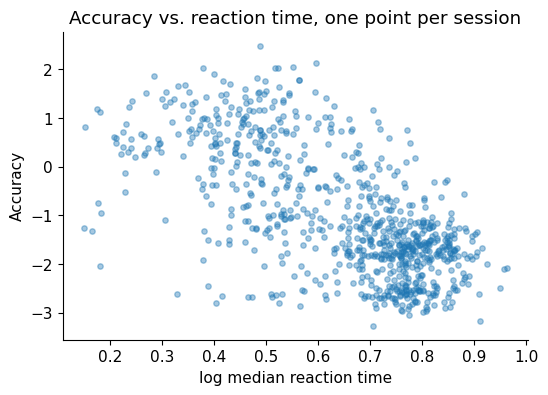

In [4]:
# TODO 3.1 - this cell has a bug: the x and y data are swapped relative to the labels/title.
#            Fix it so log_rt is on x and accuracy is on y, then run it.
fig, ax = plt.subplots()
ax.scatter(df["accuracy"], df["log_rt"], alpha=0.4, s=15)   # <-- x and y are swapped here
ax.set_xlabel("log median reaction time")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. reaction time, one point per session")
plt.show()


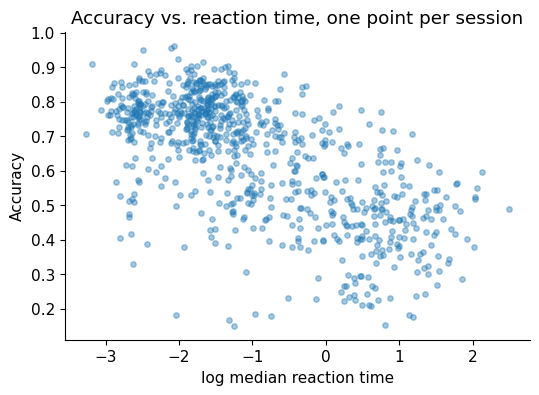

In [5]:
# Solution 3.1
fig, ax = plt.subplots()
ax.scatter(df["log_rt"], df["accuracy"], alpha=0.4, s=15)   # log_rt on x, accuracy on y
ax.set_xlabel("log median reaction time")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. reaction time, one point per session")
plt.show()
# Bug fixed: the arguments to scatter were swapped relative to the axis labels.
# Accuracy falls as sessions get slower, in a way that is close enough to a straight
# line to fit one, and a few sessions sit far to the right: days when the mouse was
# barely working. Those are the points the robust regression in Section 11 deals with.


**▶ Task 3.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 3.2 ⭐ — Stimulus vs. response angle.**
> This one uses the small simulated table `circ` loaded above, since a two-choice task has no angles to report. Make the same kind of scatter plot for `stim_angle` (x-axis) against `response_angle` (y-axis).
> What looks different about this relationship compared to Task 3.1, especially near the edges of the axis range (close to 0° and close to 360°)?

In [6]:
# TODO 3.2 — write your code here



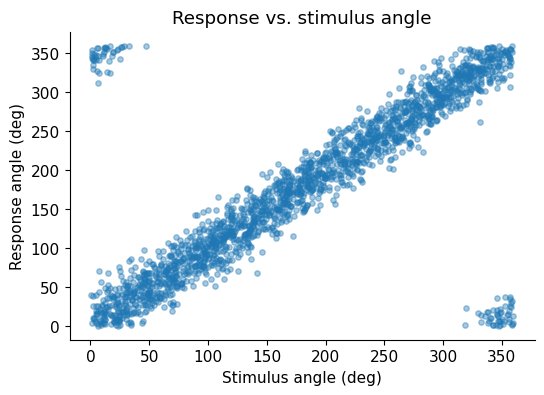

In [7]:
# Solution 3.2
fig, ax = plt.subplots()
ax.scatter(circ["stim_angle"], circ["response_angle"], alpha=0.4, s=15)
ax.set_xlabel("Stimulus angle (deg)")
ax.set_ylabel("Response angle (deg)")
ax.set_title("Response vs. stimulus angle")
plt.show()
# Note the wrap-around: points near 0 and 360 are geometrically close together,
# but the scatter plot (and any linear model) treats them as being at opposite ends.


**▶ Task 3.2 — Response: (Write your response in this Markdown cell)**

<a id="section-4"></a>
## 4. Correlation: covariance, Pearson, and Spearman

Correlation is built on **covariance**. The covariance of two variables measures how they vary *together*: it is the average product of their deviations from their means,
$$\operatorname{cov}(x, y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y}).$$
It is positive when above-average $x$ tends to go with above-average $y$, negative when they move in opposite directions. Covariance depends on the units of $x$ and $y$, so on its own it is hard to interpret.

**Pearson's r** fixes the units problem by dividing covariance by the two standard deviations, giving a number in $[-1, 1]$ that measures the strength of a *linear* association:
$$r = \frac{\operatorname{cov}(x, y)}{s_x\, s_y}.$$
**Spearman's rho** instead correlates the *ranks* of the two variables, so it captures any *monotonic* relationship (linear or not) and is more robust to outliers. When a relationship is linear-ish and outlier-free, the two agree closely; when it is monotonic-but-curved, or contaminated by outliers, they can diverge.


> **▶ Task 4.1 ⭐⭐ — Covariance and Pearson's r from scratch.**
> For `log_rt` (x) and `accuracy` (y): compute the sample **covariance** by hand, then build **Pearson's r** from it using the two standard deviations, and finally check your result against `scipy.stats.pearsonr` (and, if you like, `np.corrcoef`). Do the numbers agree?


In [8]:
# TODO 4.1 — write your code here
x = df["log_rt"].values
y = df["accuracy"].values
n = len(x)
# 1) compute the means of x and y
# 2) sample covariance:  sum((x - xbar) * (y - ybar)) / (n - 1)
# 3) sample std of x and of y
# 4) Pearson's r = cov / (std_x * std_y)
# 5) compare against stats.pearsonr(x, y)


In [9]:
# Solution 4.1
x = df["log_rt"].values
y = df["accuracy"].values
n = len(x)

x_bar, y_bar = x.mean(), y.mean()
cov_xy = np.sum((x - x_bar) * (y - y_bar)) / (n - 1)
std_x = np.sqrt(np.sum((x - x_bar) ** 2) / (n - 1))
std_y = np.sqrt(np.sum((y - y_bar) ** 2) / (n - 1))
r_scratch = cov_xy / (std_x * std_y)

print(f"covariance (from scratch): {cov_xy:.5f}")
print(f"Pearson r  (from scratch): {r_scratch:.5f}")
print(f"Pearson r  (scipy)       : {stats.pearsonr(x, y)[0]:.5f}")
print(f"np.corrcoef check        : {np.corrcoef(x, y)[0, 1]:.5f}")

# The same numbers, laid out as the covariance matrix from the lecture:
print("\ncovariance matrix of (log_rt, accuracy):")
print(np.cov(x, y, ddof=1).round(5))
# The diagonal holds the two variances; the covariance sits off the diagonal, twice,
# because cov(x, y) and cov(y, x) are the same number. Pearson's r is that off-diagonal
# entry divided by the two standard deviations.


covariance (from scratch): -0.14430
Pearson r  (from scratch): -0.65342
Pearson r  (scipy)       : -0.65342
np.corrcoef check        : -0.65342

covariance matrix of (log_rt, accuracy):
[[ 1.62478 -0.1443 ]
 [-0.1443   0.03002]]


**▶ Task 4.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 4.2 ⭐ — Correlate reaction time and accuracy.**
> Run the cell below. It computes the Pearson and the Spearman correlation between accuracy and reaction time twice: once in raw seconds, once on the logarithm. Do the two coefficients agree? Which one moves when you take the logarithm, and which one does not?

In [10]:
# TODO 4.2 - run this and answer the question below
for name in ["median_rt", "log_rt"]:
    r_pearson = stats.pearsonr(df[name], df["accuracy"])[0]
    r_spearman = stats.spearmanr(df[name], df["accuracy"])[0]
    print(f"accuracy vs {name:<9s}:  Pearson r = {r_pearson:.3f}, Spearman r = {r_spearman:.3f}")


accuracy vs median_rt:  Pearson r = -0.530, Spearman r = -0.629
accuracy vs log_rt   :  Pearson r = -0.653, Spearman r = -0.629


**Model answer (TA edition).** In raw seconds Pearson is about -0.53 and Spearman about -0.63. On the logarithm Pearson catches up to -0.65 while Spearman does not move at all. Spearman only looks at the ranking, and a logarithm reorders nothing, so it cannot change. Pearson measures how close the cloud is to a straight line, and the log straightens it, which is why we regress on `log_rt` from here on. A gap between the two is a useful warning: monotonic, but not linear.

**▶ Task 4.2 — Response: (Write your response in this Markdown cell)**

> **▶ Task 4.3 ⭐⭐ — A second predictor.**
> Sessions differ in another obvious way: some are long and some are short. Compute the Pearson and the Spearman correlation between `n_trials` and `accuracy`, and plot them against each other. Is the correlation weaker or stronger than the one with reaction time? And would you expect these two predictors to be independent of each other?

In [11]:
# TODO 4.3 - write your code here
# Correlate df["n_trials"] with df["accuracy"], then plot them.




accuracy vs n_trials:  Pearson r = 0.459, Spearman r = 0.462
log_rt   vs n_trials:  Pearson r = -0.579


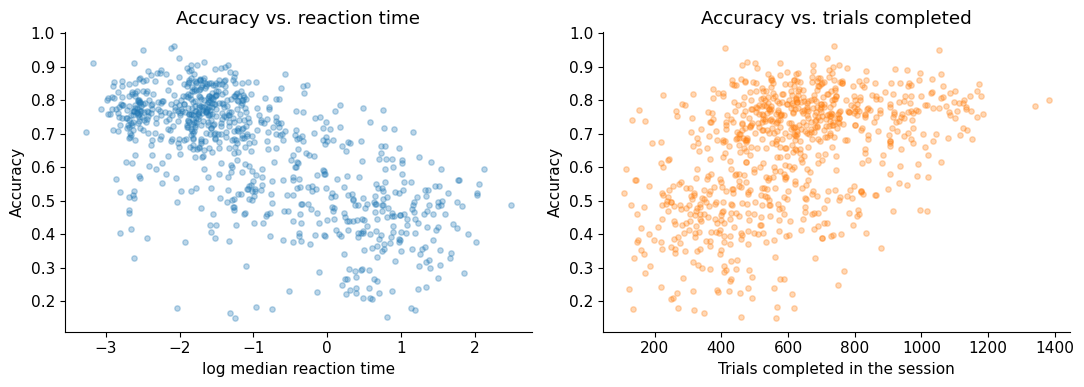

In [12]:
# Solution 4.3
r_pearson = stats.pearsonr(df["n_trials"], df["accuracy"])[0]
r_spearman = stats.spearmanr(df["n_trials"], df["accuracy"])[0]
print(f"accuracy vs n_trials:  Pearson r = {r_pearson:.3f}, Spearman r = {r_spearman:.3f}")

# The two predictors are related to each other: a mouse answering quickly gets through more trials.
print(f"log_rt   vs n_trials:  Pearson r = {stats.pearsonr(df['log_rt'], df['n_trials'])[0]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df["log_rt"], df["accuracy"], alpha=0.3, s=15)
axes[0].set_xlabel("log median reaction time")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs. reaction time")

axes[1].scatter(df["n_trials"], df["accuracy"], alpha=0.3, s=15, color="C1")
axes[1].set_xlabel("Trials completed in the session")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs. trials completed")
fig.tight_layout()
plt.show()

# Trial count carries signal too, less of it, and it is not independent of reaction time.
# Section 9 comes back to what happens when correlated predictors go into one model.


**▶ Task 4.3 — Response: (Write your response in this Markdown cell)**

> **▶ Task 4.4 ⭐⭐ — Where does the p-value of *r* come from?**
> The p-value `stats.pearsonr` returns comes from a formula that assumes the two variables are jointly normal. Here is a way to get one without assuming anything. If reaction time and accuracy were unrelated, pairing one session's reaction time with another session's accuracy would be as good as the real pairing. So shuffle one column, recompute *r*, and repeat: what you get is the range of *r* when there is nothing to find.
> Run the cell and compare the two p-values. You will meet this idea again in Week 6.

observed r          : -0.653
largest |r| shuffled: 0.140
permutation p-value : 0.00020


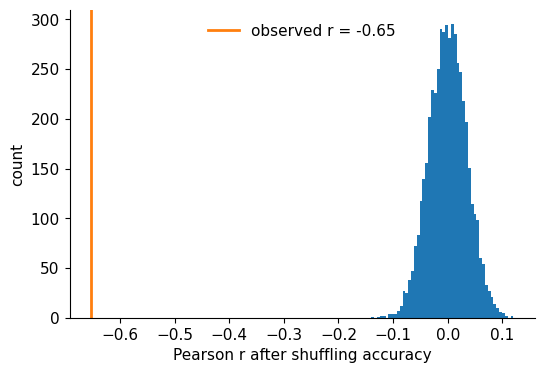

In [13]:
# TODO 4.4 - run this and answer the question below
observed_r = stats.pearsonr(df["log_rt"], df["accuracy"])[0]

rng = np.random.default_rng(7)
n_shuffles = 5000
null_r = []
for _ in range(n_shuffles):
    shuffled = rng.permutation(df["accuracy"].values)     # break the pairing, keep both columns
    null_r.append(stats.pearsonr(df["log_rt"].values, shuffled)[0])
null_r = np.array(null_r)

# The +1 counts the observed value itself, so the p-value is never exactly zero.
p_perm = (np.sum(np.abs(null_r) >= abs(observed_r)) + 1) / (n_shuffles + 1)

print(f"observed r          : {observed_r:.3f}")
print(f"largest |r| shuffled: {np.abs(null_r).max():.3f}")
print(f"permutation p-value : {p_perm:.5f}")

fig, ax = plt.subplots()
ax.hist(null_r, bins=50)
ax.axvline(observed_r, color="C1", lw=2, label=f"observed r = {observed_r:.2f}")
ax.set_xlabel("Pearson r after shuffling accuracy")
ax.set_ylabel("count")
ax.legend(frameon=False)
plt.show()


**Model answer (TA edition).** The shuffled correlations pile up around zero and never get anywhere near the observed -0.65, so the permutation p-value is as small as 5000 shuffles allow, 1 in 5001. Read it as "smaller than 0.0002 and we cannot say more", not as a number to compare with the 1e-100 that `pearsonr` prints: the formula extrapolates into a tail we never sampled, and the shuffling only knows what it drew. Both say the same thing, that no reshuffling of these sessions produces a correlation like the real one. The difference is that the shuffle assumes nothing about the shape of the data, only that the pairing is what carries the effect.

**▶ Task 4.4 — Response: (Write your response in this Markdown cell)**

<a id="section-5"></a>
## 5. Linear regression: model, design matrix, least squares, inference

A simple linear regression models the outcome as $y = \beta_0 + \beta_1 x + \varepsilon$, where $\beta_0$ is the intercept, $\beta_1$ the slope, and $\varepsilon$ the residual noise. `statsmodels` estimates $\beta_0$ and $\beta_1$ by **least squares**: the values that minimise the sum of squared residuals. Internally, it builds a **design matrix** — a table with one column of 1s (for the intercept) and one column per predictor — and solves for the coefficients using that matrix.

### The least squares criterion

For each trial $i$, the model makes a prediction $\hat{y}_i = \beta_0 + \beta_1 x_i$, and the **residual** is the gap between the observed and predicted value, $e_i = y_i - \hat{y}_i$. Least squares picks the coefficients $\beta_0, \beta_1$ that minimise the **sum of squared residuals** (also called the residual sum of squares, RSS) over all $n$ trials:

$$
\text{RSS}(\beta_0, \beta_1) = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} \big(y_i - \beta_0 - \beta_1 x_i\big)^2
$$

We square the residuals so that positive and negative errors don't cancel out, and so that large errors are penalised disproportionately more than small ones (a point we'll come back to in Section 11, when a few large residuals end up dominating the fit).

### Why it has a closed-form solution

$\text{RSS}(\beta_0, \beta_1)$ is a smooth, bowl-shaped (quadratic, convex) function of $\beta_0$ and $\beta_1$, so it has a single minimum, found where its partial derivatives with respect to $\beta_0$ and $\beta_1$ are both zero. Solving that pair of equations for the single-predictor case gives the familiar formulas

$$
\hat{\beta}_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

where $\bar{x}$ and $\bar{y}$ are the sample means of $x$ and $y$. Notice the numerator of $\hat{\beta}_1$ is (proportional to) the covariance of $x$ and $y$, and the denominator is the variance of $x$ — the least-squares slope is essentially a rescaled covariance, which is also why it's closely related to the Pearson correlation from Section 4.

### The design-matrix (matrix) form

This is exactly what `statsmodels` computes, but written more generally so it extends directly to multiple predictors, polynomial terms (Section 9), and interactions (Section 9). Stack the intercept column of 1s and the predictor(s) into the design matrix $X$ (an $n \times p$ matrix, one row per trial, one column per parameter), and stack the outcomes into a vector $\mathbf{y}$. The model is then

$$
\mathbf{y} = X\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

and the least-squares estimate $\hat{\boldsymbol{\beta}}$ that minimises $\lVert \mathbf{y} - X\boldsymbol{\beta} \rVert^2$ (the matrix version of the RSS above) has the closed-form solution

$$
\hat{\boldsymbol{\beta}} = (X^{\top}X)^{-1}X^{\top}\mathbf{y}
$$

known as the **normal equations**. `sm.OLS(y, X).fit()` solves precisely this equation (using a numerically stable method rather than literally inverting $X^{\top}X$) — so `model.params` are $\hat{\boldsymbol{\beta}}$, and `model.fittedvalues` are $X\hat{\boldsymbol{\beta}}$.


> **▶ Task 5.1 ⭐ — Fit a linear model.**
> Run the cell below, which fits a regression of `accuracy` on `log_rt` (using `sm.add_constant` to add the intercept column) and prints `model.summary()`. What are the intercept and slope, and how would you describe each in one sentence?


In [14]:
# TODO 5.1 — run this and answer the question below
X = sm.add_constant(df["log_rt"])
y = df["accuracy"]
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               accuracy   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     608.0
Date:                Mon, 17 Aug 2026   Prob (F-statistic):          9.38e-101
Time:                        16:45:46   Log-Likelihood:                 501.46
No. Observations:                 818   AIC:                            -998.9
Df Residuals:                     816   BIC:                            -989.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5555      0.006     95.619      0.0

**Model answer (TA edition).** The intercept (about 0.56) is the predicted accuracy of a session with a median reaction time of one second, where `log_rt` is zero. The slope (about -0.089) says that multiplying the reaction time by $e$ costs about nine points of accuracy. With *t* near -25 the association is not in doubt, but the direction of the arrow is: slow sessions are inaccurate sessions, and nothing here says which causes which.

**▶ Task 5.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 5.2 ⭐ — Inspect the design matrix.**
> Print the first few rows of `X` (the design matrix built above). What does `sm.add_constant` actually add, and why is it needed to estimate an intercept?


In [15]:
# TODO 5.2 — write your code here



In [16]:
# Solution 5.2
print(X.head())
print("\nShape of design matrix:", model.model.exog.shape)
# sm.add_constant() prepends a column of 1s, which lets the model estimate an
# intercept (the constant term) alongside the slope on 'log_rt'.


   const    log_rt
0    1.0  1.469808
1    1.0  1.705484
2    1.0  1.047793
3    1.0  0.682920
4    1.0  0.418447

Shape of design matrix: (818, 2)


**▶ Task 5.2 — Response: (Write your response in this Markdown cell)**

For reference, `statsmodels` also offers an R-style **formula** interface, which builds the same design matrix for you from a string:


In [17]:
# --- Equivalent fit using the formula API
formula_model = smf.ols("accuracy ~ log_rt", data=df).fit()
print(formula_model.params)


Intercept    0.555531
log_rt      -0.088815
dtype: float64


> **▶ Task 5.3 ⭐⭐ — Inference on the slope.**
> The summary table reports more than just the slope. Reconstruct that inference yourself from the fitted `model`: extract the slope $\hat{\beta}_1$ on `log_rt`, its **standard error**, form the **t-statistic** $t = \hat{\beta}_1 / \text{SE}$, read off the **p-value**, and get the **95% confidence interval**. Check that your numbers match the `log_rt` row of `model.summary()`.
> *Useful attributes:* `model.params`, `model.bse`, `model.tvalues`, `model.pvalues`, `model.conf_int()`.


In [18]:
# TODO 5.3 — write your code here
# Reconstruct: beta_1, its standard error, t = beta_1/SE, the p-value, and the 95% CI.



In [19]:
# Solution 5.3
beta1 = model.params["log_rt"]
se1 = model.bse["log_rt"]
t1 = beta1 / se1
p1 = model.pvalues["log_rt"]
ci_low, ci_high = model.conf_int().loc["log_rt"]

print(f"beta_1 (slope) : {beta1:.4f}")
print(f"standard error : {se1:.4f}")
print(f"t = beta_1/SE  : {t1:.3f}   (statsmodels: {model.tvalues['log_rt']:.3f})")
print(f"p-value        : {p1:.3e}")
print(f"95% CI         : [{ci_low:.4f}, {ci_high:.4f}]")
# These reproduce the 'log_rt' row of model.summary(): coef, std err, t, P>|t|, and [0.025, 0.975].
# t is large and the CI is far from 0, so the slope is significantly different from zero.


beta_1 (slope) : -0.0888
standard error : 0.0036
t = beta_1/SE  : -24.657   (statsmodels: -24.657)
p-value        : 9.380e-101
95% CI         : [-0.0959, -0.0817]


**▶ Task 5.3 — Response: (Write your response in this Markdown cell)**

<a id="section-6"></a>
## 6. Design matrices: a worked example

Section 5 introduced the design matrix $X$ in the abstract: a column of 1s for the intercept, plus one column per predictor, so that $\hat{\mathbf{y}} = X\hat{\boldsymbol{\beta}}$. Let's make it concrete on five sessions drawn from `df`, few enough to print the whole matrix and check the arithmetic by hand, before trusting `statsmodels` to build it for us on all 818.


In [20]:
# --- Five sessions taken at random, small enough to print the design matrix in full
toy = df.sample(5, random_state=2)[["log_rt", "accuracy"]]
print(toy.round(3).to_string(index=False))

# Build the design matrix by hand: a column of 1s, then one column per predictor
X_toy = np.column_stack([
    np.ones(len(toy)),   # intercept column
    toy["log_rt"],       # one column for the log_rt predictor
])
y_toy = toy["accuracy"].values

print("\nDesign matrix X_toy (intercept column | log_rt column):")
print(X_toy.round(3))


 log_rt  accuracy
 -1.505     0.752
  0.438     0.572
  1.388     0.487
  0.581     0.735
 -0.318     0.823

Design matrix X_toy (intercept column | log_rt column):
[[ 1.    -1.505]
 [ 1.     0.438]
 [ 1.     1.388]
 [ 1.     0.581]
 [ 1.    -0.318]]


Each **row** of `X_toy` is one session; each **column** is one parameter of the model. Row $i$, dotted with the coefficient vector $\boldsymbol{\beta} = (\beta_0, \beta_1)$, gives that session's prediction $\hat{y}_i = \beta_0 \cdot 1 + \beta_1 \cdot x_i$ — which is exactly why the intercept needs its own column of constant 1s: it's just a predictor that never changes.

Now let's solve the normal equations from Section 5, $\hat{\boldsymbol{\beta}} = (X^{\top}X)^{-1}X^{\top}\mathbf{y}$, by hand with `numpy`, and check that we get the same answer as `sm.OLS`.


In [21]:
# --- Solve the normal equations by hand, then compare to sm.OLS
beta_hand = np.linalg.inv(X_toy.T @ X_toy) @ X_toy.T @ y_toy
print("beta from normal equations (by hand):", beta_hand.round(4))

toy_model = sm.OLS(y_toy, X_toy).fit()
print("beta from sm.OLS:                    ", toy_model.params.round(4))
# Five sessions give a noisy estimate of the slope, and this one happens to land close
# to the -0.089 that the full table gave in Section 5.


beta from normal equations (by hand): [ 0.6845 -0.091 ]
beta from sm.OLS:                     [ 0.6845 -0.091 ]


The two match (up to floating-point rounding) — `sm.OLS` is solving exactly the equation from Section 5, just with a numerically safer algorithm than a literal matrix inverse.

### Adding more columns: categorical predictors

The real power of the design-matrix view is that it scales to more than one predictor without changing the recipe at all — every extra predictor is just one more column. This includes **categorical** predictors, like `subject_id`: instead of a single numeric column, a categorical variable with $k$ levels gets turned into $k-1$ **dummy (indicator) columns** (one level is left out as the *reference level*, so the intercept represents that reference level, and each dummy coefficient represents the *offset* from it). `statsmodels`'s formula interface (`C(...)`) builds these dummy columns for us automatically — this is what happens under the hood in Section 9's `log_rt * C(subject_id)` interaction model.

Let's see it explicitly on two sessions each from three mice:


In [22]:
# --- The dummy-coded design matrix statsmodels builds for a categorical predictor
three_mice = ["CSHL045", "CSHL046", "CSHL047"]
toy_subjects = df[df["subject_id"].isin(three_mice)].groupby("subject_id").head(2)
print(toy_subjects[["subject_id", "session", "log_rt", "accuracy"]].round(3).to_string(index=False))

# patsy, the formula engine inside statsmodels, builds the design matrix for us
built = smf.ols("accuracy ~ log_rt + C(subject_id)", data=toy_subjects)
print("\n", pd.DataFrame(built.exog, columns=built.exog_names).round(3), sep="")


subject_id  session  log_rt  accuracy
   CSHL045        1   1.470     0.545
   CSHL045        2   1.705     0.431
   CSHL046        1   1.498     0.496
   CSHL046        2   1.660     0.331
   CSHL047        1   1.388     0.487
   CSHL047        2   1.283     0.358

   Intercept  C(subject_id)[T.CSHL046]  C(subject_id)[T.CSHL047]  log_rt
0        1.0                       0.0                       0.0   1.470
1        1.0                       0.0                       0.0   1.705
2        1.0                       1.0                       0.0   1.498
3        1.0                       1.0                       0.0   1.660
4        1.0                       0.0                       1.0   1.388
5        1.0                       0.0                       1.0   1.283


Notice `CSHL045` gets **no** dummy column of its own: it *is* the reference level, absorbed into the intercept. The columns `C(subject_id)[T.CSHL046]` and `C(subject_id)[T.CSHL047]` are 1 exactly on the rows for that mouse and 0 otherwise, so each of their coefficients is the *difference* in intercept between that mouse and CSHL045.

### The whole matrix, as a picture

Six rows fit on the screen. The real one has 818, so we look at it instead of printing it.

This is also where the **vectorization** from Notebook 2, section 1.3, pays off. Predicting one session is a small sum: the intercept, plus the slope times that session's `log_rt`, plus the offset of the mouse it belongs to. Doing that for 818 sessions could be a loop of 818 small sums. Stacking the sessions into a matrix turns it into one multiplication, $X\hat{\boldsymbol{\beta}}$, which NumPy carries out in a single call. The image below is that loop laid out flat: every row a session waiting to be predicted, every column a number the model has to learn.

Read as a model rather than as a picture, this one gives **every mouse its own baseline and all of them the same slope**. The staircase columns are flags, they only say which animal a session belongs to; the single column on the right carries the reaction times of all thirty. Thirty parallel lines, same tilt, different heights. Section 9 relaxes that with an interaction, one slope per mouse, which in this picture would be a second staircase whose blocks hold numbers instead of flags.

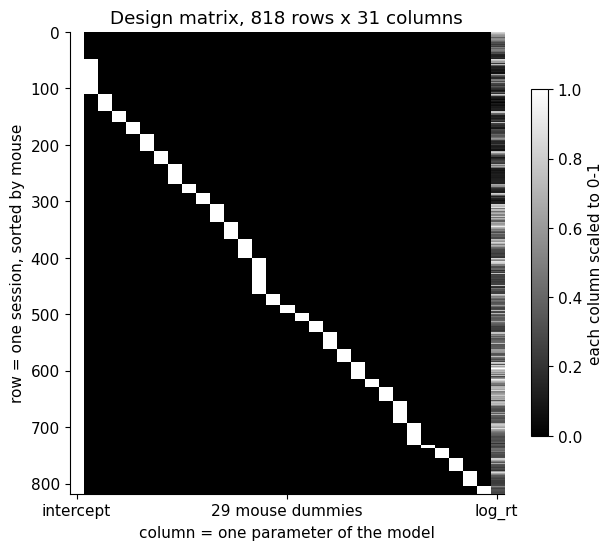

In [23]:
# --- The same recipe on the whole table, drawn rather than printed
model_all = smf.ols("accuracy ~ log_rt + C(subject_id)",
                    data=df.sort_values(["subject_id", "session"]))
X_all = pd.DataFrame(model_all.exog, columns=model_all.exog_names)

# Each column is scaled to 0-1 on its own, otherwise the 0/1 dummy columns and log_rt,
# which runs from -3.3 to 2.5, cannot share one colour scale.
X_shown = X_all.copy()
for column in X_all.columns:
    spread = X_all[column].max() - X_all[column].min()
    X_shown[column] = 1.0 if spread == 0 else (X_all[column] - X_all[column].min()) / spread

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(X_shown.values, cmap="gray", aspect="auto", interpolation="nearest")
ax.set_xticks([0, 15, 30])
ax.set_xticklabels(["intercept", "29 mouse dummies", "log_rt"])
ax.set_xlabel("column = one parameter of the model")
ax.set_ylabel("row = one session, sorted by mouse")
ax.set_title(f"Design matrix, {X_all.shape[0]} rows x {X_all.shape[1]} columns")
fig.colorbar(im, ax=ax, shrink=0.75, label="each column scaled to 0-1")
plt.show()

# White stripe on the left: the intercept, 1 in every row.
# The staircase: one column per mouse, white on that mouse's sessions, black elsewhere.
# The rows at the top with no white block anywhere are the reference mouse, the one
# absorbed into the intercept. The speckled column on the right is log_rt itself.
# One slope for everybody, one baseline each: that is what "+ C(subject_id)" buys.
# You will meet this picture again as the design matrix of an fMRI experiment.


**Reflection.** Whether it's a single numeric predictor, several numeric predictors, dummy-coded categorical levels, polynomial terms, or interactions, the design matrix treats them all the same way: as columns to be multiplied by coefficients and added together. Sections 9 and 10 build on this directly — a polynomial term or an interaction is nothing more than another column computed from the existing predictors before the same least-squares machinery is applied.

<a id="section-7"></a>
## 7. Residual diagnostics

A linear regression comes with assumptions: residuals should have roughly constant variance (homoscedasticity), be approximately normally distributed, and be uncorrelated with the fitted values. Two quick diagnostic plots let us check this by eye: **residuals vs. fitted values**, and a **Q-Q plot** of the residuals.


> **▶ Task 7.1 ⭐ — Residuals vs. fitted values.**
> Run the cell below, which plots `model.resid` against `model.fittedvalues` (using the model from Task 5.1) with a horizontal reference line at 0. What pattern would indicate a problem with the constant-variance assumption?


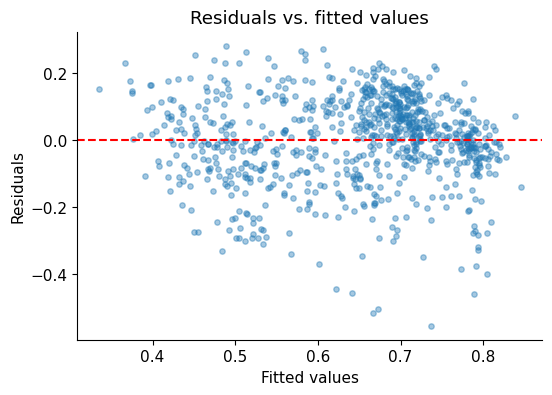

In [24]:
# TODO 7.1 — run this and answer the question below
fig, ax = plt.subplots()
ax.scatter(model.fittedvalues, model.resid, alpha=0.4, s=15)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs. fitted values")
plt.show()


**Model answer (TA edition).** A *funnel*, the spread of the residuals growing or shrinking with the fitted value, is what would signal non-constant variance. Here the spread is fairly steady, between about 0.10 and 0.15 across the whole range, so the assumption holds up. What the plot does show is **asymmetry**: at the high end the largest positive residuals shrink to about 0.17 while the negative ones reach -0.5. A session predicted at 80 per cent correct has little room above and plenty below. Proportions behave like that near their ceiling, which is a first hint that a model built for proportions would suit this outcome better than plain least squares.

**▶ Task 7.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 7.2 ⭐ — Q-Q plot of residuals.**
> Use `sm.qqplot(model.resid, line="45", fit=True)` to check whether the residuals look approximately normal. Where do the points leave the line, and which sessions are they?

In [25]:
# TODO 7.2 — write your code here



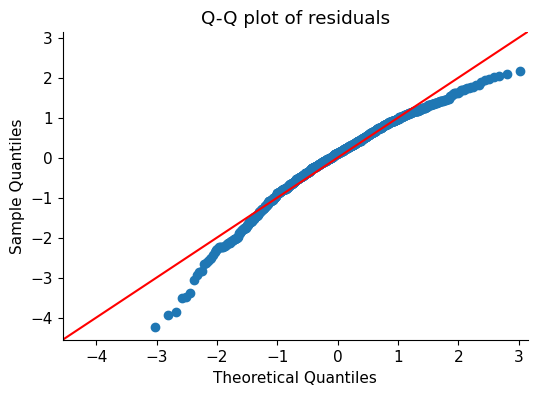

In [26]:
# Solution 7.2
sm.qqplot(model.resid, line="45", fit=True)
plt.title("Q-Q plot of residuals")
plt.show()
# The points follow the line through the middle and peel away at the bottom left: the
# residuals have a long tail of sessions that did much worse than predicted, and nothing
# comparable on the other side. Seven sessions sit more than three standard deviations
# below the fit, none that far above. It is the ceiling on accuracy again, so the normality
# assumption fails here in a specific and interpretable way rather than at random.


**▶ Task 7.2 — Response: (Write your response in this Markdown cell)**

**Reflection.** Beyond these two plots, it's also worth checking for influential points (Cook's distance — we'll do this in Section 11) and for correlation between residuals from the same subject, which a plain OLS model ignores.


<a id="section-8"></a>
## 8. When linear regression fails: circular relationships (synthetic add-on)

> **Note.** This section is a **self-contained synthetic add-on**: it uses the simulated `stim_angle`/`response_angle` variables and is *not* swapped for real data, because the IBL 2-alternative forced-choice task has no circular (orientation/phase) variable. The lesson — that ordinary linear regression cannot handle variables that wrap around — is general and worth seeing at least once.

Recall the `stim_angle` vs. `response_angle` scatter plot from Task 3.2 — angles wrap around at 360°, so 359° and 1° are actually close together, but an ordinary linear model has no notion of that.


> **▶ Task 8.1 ⭐⭐ — Fit a (bad) linear model to circular data.**
> Run the cell below, which fits `sm.OLS` of `response_angle` on `stim_angle` and overlays the fitted line on the scatter plot. Where does the fit look reasonable, and where does it clearly fail? Why?


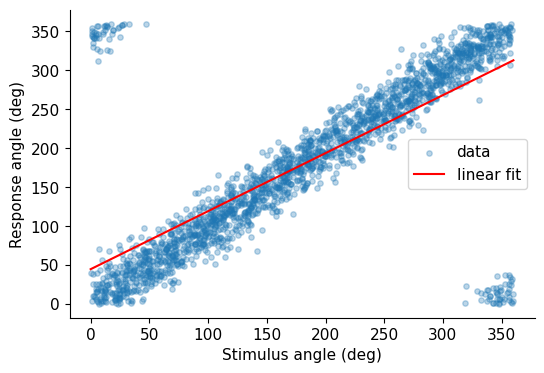

In [27]:
# TODO 8.1 — run this and answer the question below
X_angle = sm.add_constant(circ["stim_angle"])
angle_model = sm.OLS(circ["response_angle"], X_angle).fit()

fig, ax = plt.subplots()
ax.scatter(circ["stim_angle"], circ["response_angle"], alpha=0.3, s=15, label="data")
xs = np.linspace(0, 360, 200)
ax.plot(xs, angle_model.params["const"] + angle_model.params["stim_angle"] * xs,
        color="red", label="linear fit")
ax.set_xlabel("Stimulus angle (deg)")
ax.set_ylabel("Response angle (deg)")
ax.legend()
plt.show()


all points : slope 0.745, intercept 44.9, R2 0.553
wrap removed: slope 0.983, intercept 3.0, R2 0.962
points dropped: 92 out of 2000


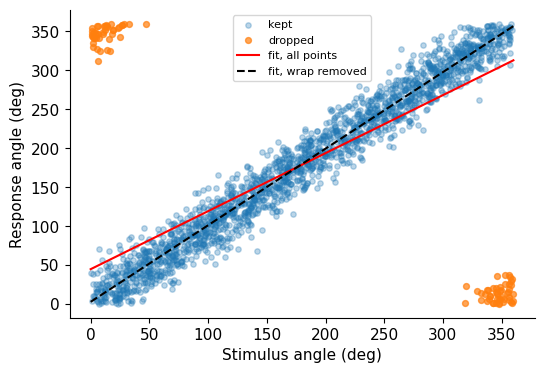

In [28]:
# --- A tempting shortcut: drop the points that wrapped, then fit again
# We can only do this because we made the data and know which points wrapped.
wrapped = (circ["response_angle"] - circ["stim_angle"]).abs() > 180
clean = circ[~wrapped]
clean_model = sm.OLS(clean["response_angle"], sm.add_constant(clean["stim_angle"])).fit()

for label, fit in [("all points ", angle_model), ("wrap removed", clean_model)]:
    print(f"{label}: slope {fit.params['stim_angle']:.3f}, "
          f"intercept {fit.params['const']:.1f}, R2 {fit.rsquared:.3f}")
print(f"points dropped: {wrapped.sum()} out of {len(circ)}")

xs = np.linspace(0, 360, 200)
fig, ax = plt.subplots()
ax.scatter(clean["stim_angle"], clean["response_angle"], alpha=0.3, s=15, label="kept")
ax.scatter(circ.loc[wrapped, "stim_angle"], circ.loc[wrapped, "response_angle"],
           alpha=0.7, s=18, color="C1", label="dropped")
ax.plot(xs, angle_model.predict(sm.add_constant(xs)), color="red", label="fit, all points")
ax.plot(xs, clean_model.predict(sm.add_constant(xs)), color="black", ls="--",
        label="fit, wrap removed")
ax.set_xlabel("Stimulus angle (deg)")
ax.set_ylabel("Response angle (deg)")
ax.legend(fontsize=8)
plt.show()

# The fit is now nearly perfect, and it is still the wrong answer. We could only find those
# points because we made the data, they are exactly the trials nearest the reference angle
# rather than a random sample, and without them the model says nothing about that part of
# the circle. Task 8.2 changes the coordinates instead of deleting the awkward data.


**Model answer (TA edition).** The line fits reasonably through the middle of the range but fails badly near 0°/360°: because angles wrap around, points near 0° and near 360° are geometrically close, yet the linear model treats them as maximally far apart. It cannot follow the wrap, so it systematically mis-predicts at the boundaries of the range. The cell above also shows what happens if we simply delete the wrapped points: the fit becomes almost perfect, which is exactly why that shortcut is dangerous.

**▶ Task 8.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 8.2 ⭐⭐⭐ — Work in sine/cosine space (optional).**
> Convert `stim_angle` and `response_angle` to `sin`/`cos` components (`np.sin(np.deg2rad(...))`, `np.cos(np.deg2rad(...))`), then fit two linear models predicting `resp_sin` and `resp_cos` from `stim_sin` and `stim_cos`. Why does this representation respect the circular geometry better than fitting on raw degrees?


In [29]:
# TODO 8.2 (optional) — write your code here



In [30]:
# Solution 8.2
circ["stim_sin"] = np.sin(np.deg2rad(circ["stim_angle"]))
circ["stim_cos"] = np.cos(np.deg2rad(circ["stim_angle"]))
circ["resp_sin"] = np.sin(np.deg2rad(circ["response_angle"]))
circ["resp_cos"] = np.cos(np.deg2rad(circ["response_angle"]))

circ_model_sin = smf.ols("resp_sin ~ stim_sin + stim_cos", data=circ).fit()
circ_model_cos = smf.ols("resp_cos ~ stim_sin + stim_cos", data=circ).fit()
print("Sin-transformed model")
print(circ_model_sin.params)
print("Cos-transformed model")
print(circ_model_cos.params)

# sin/cos map the angle onto the unit circle, where 359 deg and 1 deg are genuinely close.
# A predicted (sin, cos) pair can be turned back into an angle with arctan2, and there is no
# artificial discontinuity at 0/360 degrees -- the circular geometry is respected. The fit on


Sin-transformed model
Intercept    0.002403
stim_sin     0.941466
stim_cos     0.008203
dtype: float64
Cos-transformed model
Intercept    0.000519
stim_sin     0.006906
stim_cos     0.940357
dtype: float64


**▶ Task 8.2 — Response: (Write your response in this Markdown cell)**

<a id="section-9"></a>
## 9. Polynomial terms and interactions

Adding polynomial terms (e.g. `log_rt**2`) lets a linear model capture curvature; adding **interaction** terms (e.g. `log_rt * subject`) lets the slope of one predictor depend on the level of another. Both are powerful, and both can overfit if used carelessly — more terms will (mechanically) improve the fit to the data you have, without necessarily reflecting the true underlying process. As such, they would be very poor at generalising.


> **▶ Task 9.1 ⭐⭐ — Linear vs. quadratic fit.**
> Looking back at the scatter plot, the cloud is not exactly a straight line: accuracy flattens out at the fast end rather than falling forever. The cell below fits a linear model and a quadratic model of `accuracy` on `log_rt` and plots both fitted curves over the data. Run it. Does the quadratic term help (compare $R^2$)? Would a higher-order polynomial help more, or would it just be fitting noise?

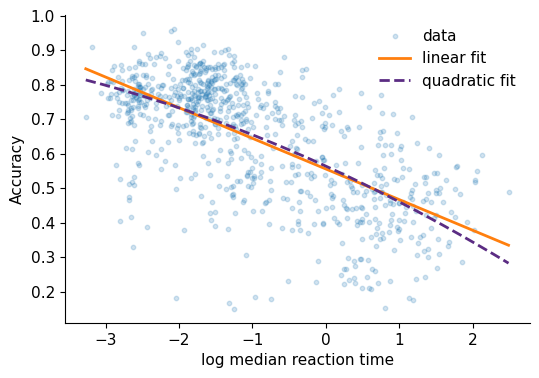

Linear R-squared:    0.42695137713113585
Quadratic R-squared: 0.4304211583356058
Difference between the two fits: 0.003469781204469946


In [31]:
# TODO 9.1 - run this and answer the question below
linear_fit = smf.ols("accuracy ~ log_rt", data=df).fit()
quad_fit = smf.ols("accuracy ~ log_rt + I(log_rt**2)", data=df).fit()

xs = np.linspace(df["log_rt"].min(), df["log_rt"].max(), 200)
pred_linear = linear_fit.predict(pd.DataFrame({"log_rt": xs}))
pred_quad = quad_fit.predict(pd.DataFrame({"log_rt": xs}))

fig, ax = plt.subplots()
ax.scatter(df["log_rt"], df["accuracy"], alpha=0.2, s=10, label="data")
ax.plot(xs, pred_linear, color="C1", lw=2, label="linear fit")
ax.plot(xs, pred_quad, color="C2", lw=2, ls="--", label="quadratic fit")
ax.set_xlabel("log median reaction time")
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
plt.show()

print("Linear R-squared:   ", linear_fit.rsquared)
print("Quadratic R-squared:", quad_fit.rsquared)
print("Difference between the two fits:", quad_fit.rsquared - linear_fit.rsquared)


**Model answer (TA edition).** The quadratic term is significant (*p* about 0.03) and buys almost nothing: $R^2$ goes from 0.427 to 0.430. The curvature is real and it is tiny. With 818 sessions even a very small departure from a straight line reaches significance, which is the difference between statistically detectable and worth keeping in the model.

**▶ Task 9.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 9.2 ⭐⭐ — An interaction with subject.**
> Fit `accuracy ~ log_rt * C(subject_id)` and print the first 10 estimated coefficients. What does one of the interaction coefficients tell you? With 30 mice, how many extra parameters does this interaction add, and why should you be cautious about adding many interaction terms as the number of conditions grows?

In [32]:
# TODO 9.2 — write your code here



In [33]:
# Solution 9.2
interaction_fit = smf.ols("accuracy ~ log_rt * C(subject_id)", data=df).fit()
print(interaction_fit.params.head(10))
print("Number of parameters:", len(interaction_fit.params))
# Each interaction coefficient says how much that mouse's slope on log_rt differs from
# the reference mouse's slope. With 30 mice that is 29 extra intercepts and 29 extra
# slopes, sixty parameters for 818 sessions. Interactions multiply quickly, using up
# degrees of freedom and making the model harder to interpret and prone to overfitting.
# A mixed-effects model is often a better tool for subject-level variability than
# manually adding interaction terms -- you will see this next week, stay tuned!


Intercept                   0.576334
C(subject_id)[T.CSHL046]   -0.018864
C(subject_id)[T.CSHL047]   -0.079370
C(subject_id)[T.CSHL049]   -0.150977
C(subject_id)[T.CSHL051]   -0.021498
C(subject_id)[T.CSHL053]   -0.281849
C(subject_id)[T.CSHL054]    0.041241
C(subject_id)[T.CSHL055]   -0.097352
C(subject_id)[T.CSHL059]   -0.055929
C(subject_id)[T.CSHL060]   -0.032190
dtype: float64
Number of parameters: 60


**▶ Task 9.2 — Response: (Write your response in this Markdown cell)**

<a id="section-10"></a>
## 10. Train/test split and cross-validation: inference vs. prediction

So far every model has been fit on the whole dataset and interpreted through its coefficients — that's *inference*. If the goal is instead *prediction* (generalising to new trials), we need to check performance on data the model hasn't seen.


> **▶ Task 10.1 ⭐⭐ — A basic train/test split.**
> The cell below defines a helper `r_squared`, splits `df` into an 80% train and 20% test set, fits `accuracy ~ log_rt` on the training set only, and computes $R^2$ on both sets. Run it. Are the two values similar? Explain why.


In [34]:
# TODO 10.1 — run this and answer the question below
def r_squared(fit, data, target):
    '''Helper function to calculate the R-squared of a fitted model on a dataset.'''
    preds = fit.predict(data)
    ss_res = np.sum((data[target] - preds) ** 2)
    ss_tot = np.sum((data[target] - data[target].mean()) ** 2)
    return 1 - ss_res / ss_tot

train_df, test_df = train_test_split(df, test_size=0.2, random_state=7)
train_fit = smf.ols("accuracy ~ log_rt", data=train_df).fit()

print("Train R-squared:", r_squared(train_fit, train_df, "accuracy"))
print("Test  R-squared:", r_squared(train_fit, test_df, "accuracy"))


Train R-squared: 0.4188897542482972
Test  R-squared: 0.45422055381497595


**Model answer (TA edition).** The two values are close, about 0.42 on the training set and 0.45 on the test set, the test one slightly higher. That is just which sessions landed in which half: a straight line has two parameters and 650 training points, so there is nothing for it to memorise. The gap opens only once the model is flexible enough to chase noise, which is Task 10.2.

**▶ Task 10.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 10.2 ⭐⭐ — Overfitting with polynomial degree.**
> For polynomial degrees 1, 2, 4, and 8, fit `accuracy` as a polynomial in `log_rt` on `train_df`, and print the train and test $R^2$ for each. What happens to each as the degree increases, and how does that illustrate the difference between fitting for inference vs. fitting for prediction?


In [35]:
# TODO 10.2 — write your code here



In [36]:
# Solution 10.2
for degree in [1, 2, 4, 8]:
    formula = "accuracy ~ " + " + ".join(
        [f"I(log_rt**{d})" for d in range(1, degree + 1)]
    )
    fit_d = smf.ols(formula, data=train_df).fit()
    train_r2 = r_squared(fit_d, train_df, "accuracy")
    test_r2 = r_squared(fit_d, test_df, "accuracy")
    print(f"Degree {degree}: train R2 = {train_r2:.3f}, test R2 = {test_r2:.3f}")
# Train R-squared can only go up as terms are added. Test R-squared is the interesting
# column: here it improves up to degree 4, so some of the curvature is real, and then
# falls again at degree 8, where the extra terms are fitting noise. The best model for
# prediction is not the one that fits the training data best.


Degree 1: train R2 = 0.419, test R2 = 0.454
Degree 2: train R2 = 0.423, test R2 = 0.456
Degree 4: train R2 = 0.459, test R2 = 0.506
Degree 8: train R2 = 0.467, test R2 = 0.488


**▶ Task 10.2 — Response: (Write your response in this Markdown cell)**

> **▶ Task 10.3 ⭐⭐⭐ — Cross-validation.**
> A single train/test split is noisy — the estimate depends on which 20% happened to land in the test set. **k-fold cross-validation** averages over several splits: partition the data into $k$ folds, and for each fold, train on the other $k-1$ and test on the held-out fold. Using `sklearn`'s `KFold` (already imported), estimate the cross-validated $R^2$ (mean and standard deviation across folds) for polynomial degrees 1, 2, 4, and 8. Which degree generalises best, and how does the *variability* across folds change with degree?


In [37]:
# TODO 10.3 — write your code here
# Hint: KFold(n_splits=5, shuffle=True, random_state=7).split(df) yields (train_idx, test_idx).
# Reuse the r_squared helper from Task 10.1.



In [38]:
# Solution 10.3
def cv_r2(degree, data, n_splits=5, seed=7):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    formula = "accuracy ~ " + " + ".join([f"I(log_rt**{d})" for d in range(1, degree + 1)])
    scores = []
    for train_idx, test_idx in kf.split(data):
        tr, te = data.iloc[train_idx], data.iloc[test_idx]
        fit = smf.ols(formula, data=tr).fit()
        scores.append(r_squared(fit, te, "accuracy"))
    return np.mean(scores), np.std(scores)

for degree in [1, 2, 4, 8]:
    m, s = cv_r2(degree, df)
    print(f"Degree {degree}: CV R2 = {m:.3f} +/- {s:.3f}")
# Averaging over five splits gives a less noisy estimate than the single split above,
# and it tells the same story: degree 4 comes out on top, degree 8 falls back. Note how
# large the spread across folds is compared to the differences between degrees. If you
# only report the winning number you are reporting partly the luck of the split, which
# is worth remembering the next time a paper compares models by a third decimal place.


Degree 1: CV R2 = 0.411 +/- 0.115


Degree 2: CV R2 = 0.414 +/- 0.113
Degree 4: CV R2 = 0.453 +/- 0.115


Degree 8: CV R2 = 0.443 +/- 0.114


**▶ Task 10.3 — Response: (Write your response in this Markdown cell)**

<a id="section-11"></a>
## 11. Robust regression: outliers and influential points

Recall the slow sessions we saw in Section 3, the days when the animal was barely engaged. Ordinary least squares minimises *squared* error, so a handful of extreme points can pull the fit disproportionately. **Robust regression** (e.g. M-estimation with Huber's T norm) downweights large residuals instead.


> **▶ Task 11.1 ⭐⭐ — OLS vs. robust regression.**
> Run the cell below, which fits `sm.OLS` and `sm.RLM` (with `sm.robust.norms.HuberT()`) of `accuracy` on `log_rt`, compares the two estimated slopes, and plots both fitted lines. Do the two slopes agree? What would it tell you about the data if they did not?

OLS slope   : -0.0888
Robust slope: -0.0901


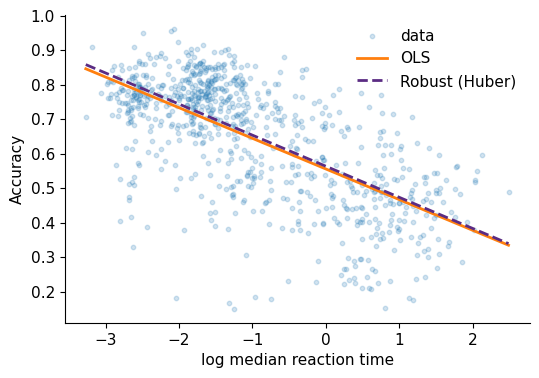

In [39]:
# TODO 11.1 - run this and answer the question below
X = sm.add_constant(df["log_rt"])
y = df["accuracy"]

ols_fit = sm.OLS(y, X).fit()
rlm_fit = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()

print(f"OLS slope   : {ols_fit.params['log_rt']:.4f}")
print(f"Robust slope: {rlm_fit.params['log_rt']:.4f}")

xs = np.linspace(df["log_rt"].min(), df["log_rt"].max(), 200)
Xs = sm.add_constant(xs)
fig, ax = plt.subplots()
ax.scatter(df["log_rt"], df["accuracy"], alpha=0.2, s=10, label="data")
ax.plot(xs, ols_fit.predict(Xs), color="C1", lw=2, label="OLS")
ax.plot(xs, rlm_fit.predict(Xs), color="C2", lw=2, ls="--", label="Robust (Huber)")
ax.set_xlabel("log median reaction time")
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
plt.show()


**Model answer (TA edition).** The two slopes are almost identical, -0.089 for OLS and -0.090 for the robust fit, so no small group of sessions is carrying the relationship. The check coming out negative is still a check worth running. Try it on the raw `median_rt` and the slopes separate (-0.068 against -0.078), because in seconds the slowest sessions sit far out on the x-axis and have real leverage.

**▶ Task 11.1 — Response: (Write your response in this Markdown cell)**

> **▶ Task 11.2 ⭐⭐ — Cook's distance.**
> Using `ols_fit.get_influence().cooks_distance`, find the 10 most influential sessions in the OLS fit. Look up what those sessions actually are in `df`. Are they the slowest ones, and if not, what do they have in common?

In [40]:
# TODO 11.2 — write your code here



Positions of the 10 most influential sessions: [242 142 243 143 187 600 254  68 145 255]
Overlap with the 10 slowest sessions: 1
    subject_id  log_rt  accuracy  n_trials
243    CSHL055  -2.687     0.473       809
142    CSHL049   1.193     0.176       319
244    CSHL055  -2.687     0.465       691
143    CSHL049   0.811     0.153       458
187    CSHL053  -2.443     0.388       701
603     NYU-08   2.125     0.596       114
255    CSHL055  -2.658     0.416       678
68     CSHL046  -2.810     0.404       497
145    CSHL049  -2.039     0.182       617
256    CSHL055  -2.621     0.329       681


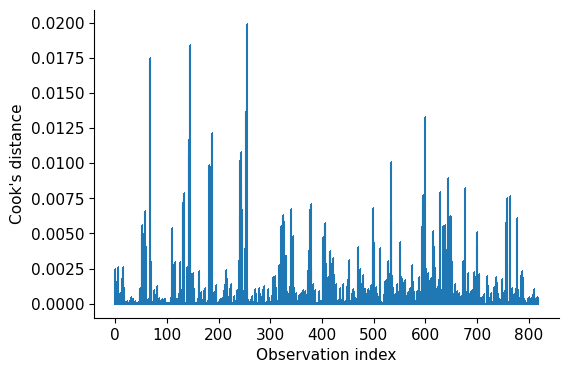

In [41]:
# Solution 11.2
influence = ols_fit.get_influence()
cooks_d, _ = influence.cooks_distance
top_influential = np.argsort(cooks_d)[-10:]
print("Positions of the 10 most influential sessions:", top_influential)

slowest = np.argsort(df["log_rt"].to_numpy())[-10:]
print("Overlap with the 10 slowest sessions:", len(set(top_influential) & set(slowest)))
print(df.iloc[top_influential][["subject_id", "log_rt", "accuracy", "n_trials"]].round(3).to_string())

fig, ax = plt.subplots()
ax.stem(cooks_d, markerfmt=",")
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's distance")
plt.show()
# Most of them are the *fastest* sessions, not the slowest: a mouse answering in a tenth
# of a second is not doing the task, and its accuracy sits near chance while the fitted
# line expects it to be high. They sit at the far left of the x-axis, which is where a
# point has the most leverage. Nobody injected them; this is what real data looks like.


**▶ Task 11.2 — Response: (Write your response in this Markdown cell)**

<a id="section-12"></a>
## 12. Fitting a curve: two ways

Every fit so far has been a straight line, or a straight line in disguise. Adding `log_rt**2` or a dummy column changes what goes into the design matrix, not the fact that the model is linear **in its parameters**, and that is what lets `statsmodels` solve it in one step with the normal equations from Section 5.

The psychometric curve is the standard example of something that is not like that: accuracy against stimulus contrast, the sigmoid you met in Week 2 and measured in Notebook 3. We start from that familiar figure, fold it into a form we can fit, and then fit it in the two ways available to us:

1. **Transform the data and keep the line.** Contrast acts roughly on a logarithmic scale, so plot accuracy against `log(contrast)` and the relationship becomes straight enough for ordinary least squares. One line of `smf.ols`, a closed-form answer, all the inference from Section 5 for free.
2. **Keep the data and fit the curve.** Write down the sigmoid, define the error it makes, and let a numerical optimiser search for the parameters that make that error smallest. No formula, no p-values out of the box, but the model is the shape you actually believe in.

The criterion is the same in both cases, the smallest squared distance between model and data. What changes is whether you bend the data to fit the tool, or the tool to fit the data.

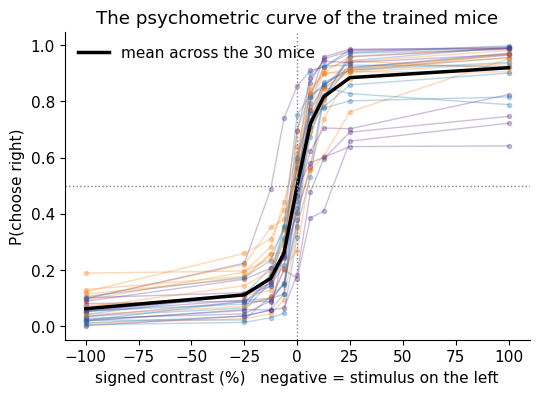

In [42]:
# --- Start from the picture you already know: the curve from Notebook 3
trained = trials[trials["phase"] == "trained"]
signed_psy = trained.groupby(["subject_id", "signed_contrast"])["response"].mean().reset_index()
group_mean = signed_psy.groupby("signed_contrast")["response"].mean()

fig, ax = plt.subplots()
for _, one_mouse in signed_psy.groupby("subject_id"):
    ax.plot(one_mouse["signed_contrast"] * 100, one_mouse["response"],
            marker="o", ms=3, lw=1, alpha=0.3)
ax.plot(group_mean.index * 100, group_mean.values, color="black", lw=2.5,
        label="mean across the 30 mice")
ax.axhline(0.5, color="grey", ls=":", lw=1)
ax.axvline(0, color="grey", ls=":", lw=1)
ax.set_xlabel("signed contrast (%)   negative = stimulus on the left")
ax.set_ylabel("P(choose right)")
ax.set_title("The psychometric curve of the trained mice")
ax.legend(frameon=False)
plt.show()


The two halves of that figure carry the same information twice. A mouse reporting *right* when the stimulus is on the right is doing the same thing as one reporting *left* when it is on the left, so we can fold the curve at zero: keep the **strength** of the contrast and ask whether the answer was **correct**. The zero-contrast trials drop out in the process, because there is no correct answer to be right about.

That is exactly the `per_mouse` table built at the start of the notebook, one row per mouse and contrast level. Folded, the curve rises from chance to a ceiling instead of running from 0 to 1, and every contrast level has one point per mouse rather than two.

subject_id  contrast  accuracy  n_trials  log_contrast
   CSHL045     0.062     0.691      1468        -2.773
   CSHL045     0.125     0.855      1485        -2.079
   CSHL045     0.250     0.928      1480        -1.386
   CSHL045     1.000     0.967      1469         0.000
   CSHL046     0.062     0.672      1309        -2.773


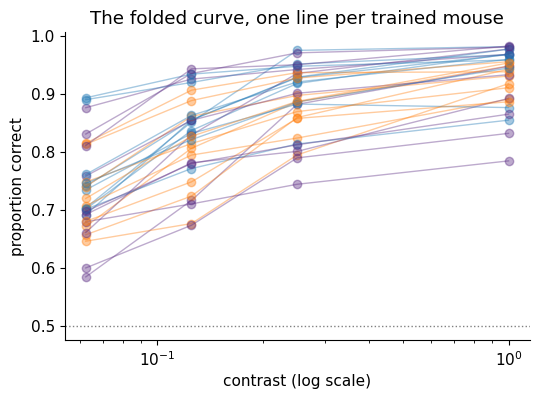

In [43]:
# --- The same curve, folded: proportion correct against contrast strength
psy = per_mouse[per_mouse["contrast"] > 0].copy()
psy["log_contrast"] = np.log(psy["contrast"])
print(psy.head().round(3).to_string(index=False))

fig, ax = plt.subplots()
for _, one_mouse in psy.groupby("subject_id"):
    ax.plot(one_mouse["contrast"], one_mouse["accuracy"], marker="o", lw=1, alpha=0.4)
ax.axhline(0.5, color="grey", ls=":", lw=1)          # chance level
ax.set_xscale("log")
ax.set_xlabel("contrast (log scale)")
ax.set_ylabel("proportion correct")
ax.set_title("The folded curve, one line per trained mouse")
plt.show()


> **▶ Task 12.1 ⭐⭐ — The same curve, fitted two ways.**
> The cell below fits both models. The straight line comes from `smf.ols` as usual. For the sigmoid it writes the loss by hand: for a given slope and bias, evaluate the sigmoid at every contrast, compare with the measured accuracies, return the RMSE. `minimize` then searches for the pair that makes it smallest. Run it.
> Over the range we measured, is either model clearly better? Now look at what each one predicts for a contrast four times higher than any the mice ever saw. Which of the two would you report, and why?

line on log contrast : RMSE 0.0705, slope 0.068
sigmoid, RMSE fit    : RMSE 0.0668, slope 0.66, bias -4.35

predicted accuracy at contrast 4.0:
  line    1.044
  sigmoid 0.978


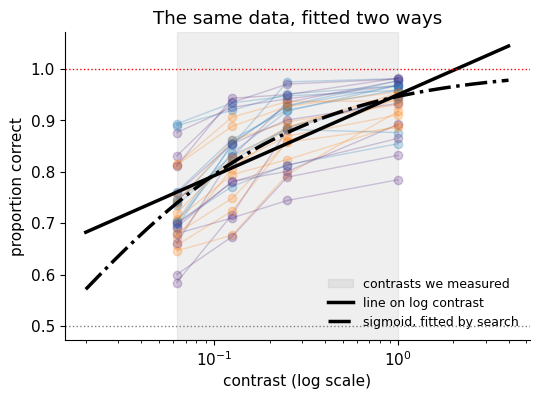

In [44]:
# TODO 12.1 - run this and answer the question below
x = psy["log_contrast"].values
y = psy["accuracy"].values

# Route 1: transform the x axis, then fit a straight line the usual way
line = smf.ols("accuracy ~ log_contrast", data=psy).fit()
rmse_line = np.sqrt(np.mean((line.predict(psy) - y) ** 2))

# Route 2: keep the sigmoid, and search for the parameters that minimise the error
def rmse(params):
    """How far the sigmoid with these parameters sits from the measured accuracies."""
    slope, bias = params
    return np.sqrt(np.mean((sigmoid(x, slope, bias) - y) ** 2))

fit = minimize(rmse, x0=[1.0, -3.0])       # x0 is where the search starts
slope_hat, bias_hat = fit.x

print(f"line on log contrast : RMSE {rmse_line:.4f}, slope {line.params['log_contrast']:.3f}")
print(f"sigmoid, RMSE fit    : RMSE {fit.fun:.4f}, slope {slope_hat:.2f}, bias {bias_hat:.2f}")

# What does each model claim about a contrast four times higher than any we measured?
far = pd.DataFrame({"log_contrast": [np.log(4.0)]})
print(f"\npredicted accuracy at contrast 4.0:")
print(f"  line    {line.predict(far)[0]:.3f}")
print(f"  sigmoid {sigmoid(np.log(4.0), slope_hat, bias_hat):.3f}")

# Draw both curves well past the contrasts we measured, so the difference is visible
grid = np.logspace(np.log10(0.02), np.log10(4.0), 200)
fig, ax = plt.subplots()
ax.axvspan(psy["contrast"].min(), psy["contrast"].max(), color="grey", alpha=0.12,
           label="contrasts we measured")
for _, one_mouse in psy.groupby("subject_id"):
    ax.plot(one_mouse["contrast"], one_mouse["accuracy"], marker="o", lw=1, alpha=0.25)
ax.plot(grid, line.predict(pd.DataFrame({"log_contrast": np.log(grid)})),
        color="black", lw=2.5, label="line on log contrast")
ax.plot(grid, sigmoid(np.log(grid), slope_hat, bias_hat),
        color="black", lw=2.5, ls="-.", label="sigmoid, fitted by search")
ax.axhline(1.0, color="red", ls=":", lw=1)           # accuracy cannot go above this
ax.axhline(0.5, color="grey", ls=":", lw=1)          # or below chance
ax.set_xscale("log")
ax.set_xlabel("contrast (log scale)")
ax.set_ylabel("proportion correct")
ax.set_title("The same data, fitted two ways")
ax.legend(frameon=False, fontsize=9)
plt.show()


**Model answer (TA edition).** Inside the shaded band, the contrasts we actually measured, the two are almost indistinguishable: RMSE 0.070 for the line against 0.067 for the sigmoid. The difference appears outside it. At four times the highest contrast the line predicts an accuracy of 1.04, which is impossible, and at the low end it stays well above chance for contrasts the mouse can barely see. The sigmoid cannot leave the interval between chance and 1, because that is built into its shape. So the transform is a fine way to describe the data you have, and the curve is what you want if the model is meant to mean anything beyond them. The price is visible in the code: no closed-form solution, a starting guess to choose, and a search that can fail if you choose it badly.

**▶ Task 12.1 — Response: (Write your response in this Markdown cell)**

<a id="section-13"></a>
## 13. Putting it all together: a mini-analysis

This is the capstone challenge. Rather than following step-by-step instructions, you now run a small analysis end to end and finish with a **scientific conclusion** — the kind of short paragraph you might write in a results section.


> **▶ Task 13.1 ⭐⭐⭐ — From raw data to a scientific conclusion.**
> Investigate the question: **"Does how fast a mouse answers predict how well it performs, and does that generalise to new sessions?"** Build a small pipeline that:
> 1. fits an OLS model of `accuracy` on `log_rt`, and reports the slope with its **95% confidence interval** (Section 5);
> 2. runs at least one **diagnostic or robustness check** — e.g. compare the OLS slope to a robust (`RLM`) slope, or inspect residuals (Sections 7, 11);
> 3. estimates **out-of-sample performance** with k-fold cross-validation (Section 10);
> 4. ends by **printing a 3–4 sentence scientific conclusion** that states the effect, its uncertainty, whether outliers drive it, and whether it generalises.
>
> There is no single right answer — you are assembling tools you have already used. Write your final interpretation in the Response cell as well.


In [45]:
# TODO 13.1 — write your end-to-end pipeline here
# Steps: (1) fit OLS + 95% CI, (2) a robustness/diagnostic check, (3) k-fold CV,
#        (4) print a short scientific conclusion.



In [46]:
# Solution 13.1 - one worked end-to-end pipeline
# Question: does a mouse that responds faster in a session also perform better,
# and does that relationship hold on sessions the model has never seen?

# 1) Fit the model and get the slope + 95% CI
Xc = sm.add_constant(df["log_rt"])
fit = sm.OLS(df["accuracy"], Xc).fit()
slope = fit.params["log_rt"]
ci_low, ci_high = fit.conf_int().loc["log_rt"]

# 2) Robustness check: does a robust fit give a similar slope?
rlm = sm.RLM(df["accuracy"], Xc, M=sm.robust.norms.HuberT()).fit()

# 3) Generalisation via 5-fold cross-validation (reusing r_squared from Task 10.1)
kf = KFold(n_splits=5, shuffle=True, random_state=7)
cv_scores = []
for tr_idx, te_idx in kf.split(df):
    tr, te = df.iloc[tr_idx], df.iloc[te_idx]
    f = smf.ols("accuracy ~ log_rt", data=tr).fit()
    cv_scores.append(r_squared(f, te, "accuracy"))
cv_mean = np.mean(cv_scores)

print(f"OLS slope     : {slope:.3f} accuracy per log-second (95% CI [{ci_low:.3f}, {ci_high:.3f}])")
print(f"Robust slope  : {rlm.params['log_rt']:.3f}")
print(f"5-fold CV R^2 : {cv_mean:.3f}")

# 4) Scientific conclusion
print(
    "\nScientific conclusion:\n"
    f"Sessions with slower responses are sessions with lower accuracy: one log-second of\n"
    f"extra reaction time costs about {abs(slope):.2f} in proportion correct, and the 95% confidence\n"
    f"interval [{ci_low:.3f}, {ci_high:.3f}] excludes zero. The robust fit gives a similar slope, so the\n"
    f"effect is not carried by a handful of unusual sessions, and cross-validation keeps about\n"
    f"R^2 = {cv_mean:.2f} on unseen sessions. Whether the animal is slow because it is disengaged, or\n"
    "inaccurate because it is slow, this analysis cannot say: both move together as it learns."
)


OLS slope     : -0.089 accuracy per log-second (95% CI [-0.096, -0.082])
Robust slope  : -0.090
5-fold CV R^2 : 0.411

Scientific conclusion:
Sessions with slower responses are sessions with lower accuracy: one log-second of
extra reaction time costs about 0.09 in proportion correct, and the 95% confidence
interval [-0.096, -0.082] excludes zero. The robust fit gives a similar slope, so the
effect is not carried by a handful of unusual sessions, and cross-validation keeps about
R^2 = 0.41 on unseen sessions. Whether the animal is slow because it is disengaged, or
inaccurate because it is slow, this analysis cannot say: both move together as it learns.


**▶ Task 13.1 — Response: (Write your response in this Markdown cell)**

<a id="section-14"></a>
## 14. Wrap-up and discussion

1. When would you report a Pearson correlation vs. a Spearman correlation in a paper, and why?
2. What does it mean for a regression to be used for *inference* rather than *prediction*? Give one example of each from this notebook.
3. Why does a linear model struggle with circular variables like orientation or phase? What variables in your own data might have this property?
4. How do you decide how many polynomial terms are "enough" without just maximising train $R^2$? How does cross-validation help?
5. What would you look for in residual diagnostics to decide whether robust regression is warranted?

**Reflection.** Every section in this notebook followed the same arc: *look at the data → summarise the relationship → fit a model → check whether the model's assumptions hold → decide whether the model is meant to explain or to predict*. That arc does not change with the size of the dataset. Here it was a few hundred sessions from thirty mice; in your own project it may be far more, and the questions you ask of a fit stay the same.


**▶ Task Section 14 — Response: (Write your response in this Markdown cell)**